# Basic Image Classification | CNN | Fashion MNIST

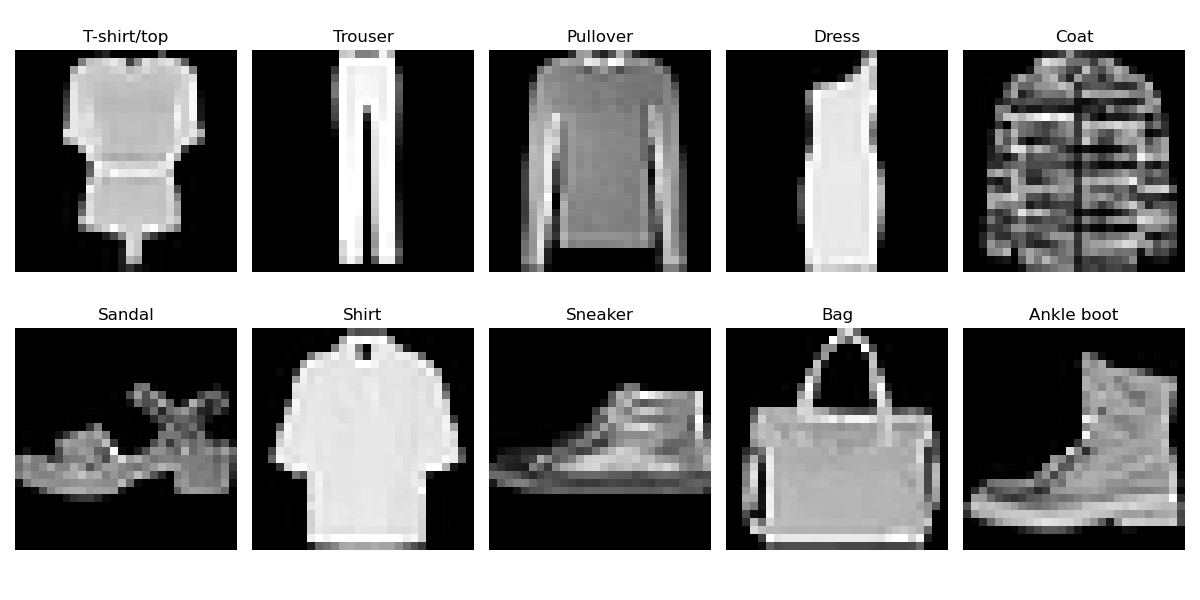

### Basic Image Classification | CNN | Fashion MNIST
This project employs Convolutional Neural Networks (CNNs) for a deep learning exploration of image classification. It utilizes the Fashion-MNIST dataset, which consists of 60,000 28x28 grayscale images across 10 fashion categories, along with test set of 10,000 images. Through a series of  experiments, we examined the effects of regularization (Dropout), network depth, and hyperparameter tuning on model performance and generalization.

## Content 
* **Load packages**
* **Data Understanding**
* **Data Preprocessing**
* **Model Development and Evaluation**
* **Results**
* **Performance Analysis on final model**
* **Saving the Model for Deployment**
* **Conclusions**
* **References and Resources**

### Load packages

In [1]:
# Import Necessary Libraries
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, Dropout, MaxPooling2D, Input 
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.callbacks import LambdaCallback, LearningRateScheduler
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.optimizers.schedules import ExponentialDecay

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import plotly.graph_objects as go
from plotly.subplots import make_subplots 
from plotly.io import show 

# Remove (%matplotlib inline) if not in Jupyter/IPython notebooks
%matplotlib inline
print(tf.__version__)

2.19.0


In [2]:
# Load the Fashion-MNIST dataset from TensorFlow Keras
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [3]:
# Define Data parameters
NUM_CLASSES = 10
IMG_ROWS = 28
IMG_COLS = 28
TEST_SIZE = 0.2
RANDOM_STATE = 42

# Define Model parameters
NO_EPOCHS = 50
BATCH_SIZE = 128

### Data Understanding

This section analyzes and confirms data integrity, identifies characteristics that might influence model design, and ensures that the data is correctly loaded and represented.

* **Display missing values:** Examination of any missing data.
* **Display shape:** Information about the number of samples, the dimensions of the images, and the structure of the labels.
* **Create dictionary:** Provide clear and meaningful labels, which facilitates better interpretation of model predictions and evaluation metrics.
* **Display images:**  Observe variations within and between different clothing categories.
* **Display class distribution:** Observe the completeness of the dataset's class representation between training and test set.

In [4]:
# Display missing values
nan_count_train_images = np.isnan(train_images).sum()
nan_count_train_labels = np.isnan(train_labels).sum()
nan_count_test_images = np.isnan(test_images).sum()
nan_count_test_labels = np.isnan(test_labels).sum()

print("NaN values in train_images:", nan_count_train_images)
print("NaN values in train_labels:", nan_count_train_labels)
print("NaN values in test_images:", nan_count_test_images)
print("NaN values in test_labels:", nan_count_test_labels)

NaN values in train_images: 0
NaN values in train_labels: 0
NaN values in test_images: 0
NaN values in test_labels: 0


In [5]:
# Display shapes
shape_train_images = train_images.shape
shape_train_labels = train_labels.shape
shape_test_images = test_images.shape
shape_test_labels = test_labels.shape

print("Shape of training images:", shape_train_images)
print("Shape of training labels:", shape_train_labels)
print("Shape of test images:", shape_test_images)
print("Shape of test labels:", shape_test_labels)

Shape of training images: (60000, 28, 28)
Shape of training labels: (60000,)
Shape of test images: (10000, 28, 28)
Shape of test labels: (10000,)


In [6]:
# Create a dictionary for each type of label 
labels = {0 : "T-shirt/top", 1: "Trouser", 2: "Pullover", 3: "Dress", 4: "Coat", 
          5: "Sandal", 6: "Shirt", 7: "Sneaker", 8: "Bag", 9: "Ankle Boot"}

print("'labels' dictionary:")
print(labels)

'labels' dictionary:
{0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat', 5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle Boot'}


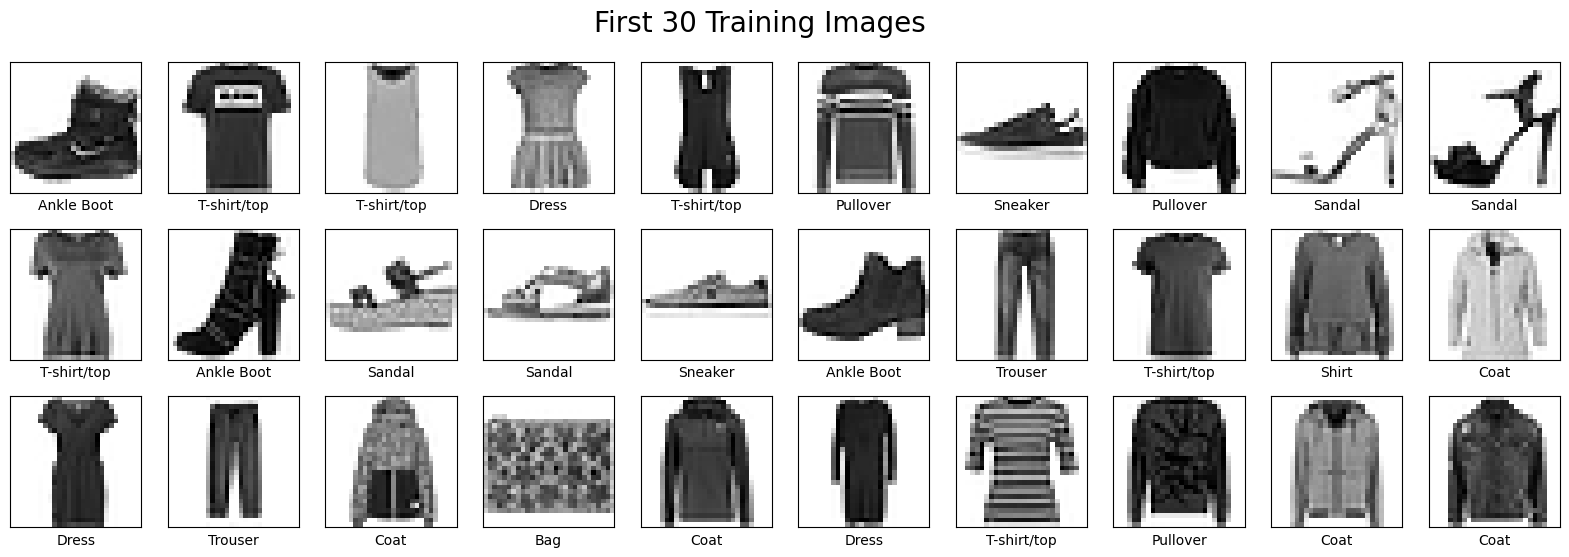

In [7]:
# Display first 30 training images
plt.figure(figsize=(20, 6))
plt.suptitle("First 30 Training Images", fontsize=20)
plt.subplots_adjust(top=0.90)

for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(labels[train_labels[i]]) 
    
#plt.tight_layout() 
plt.show()

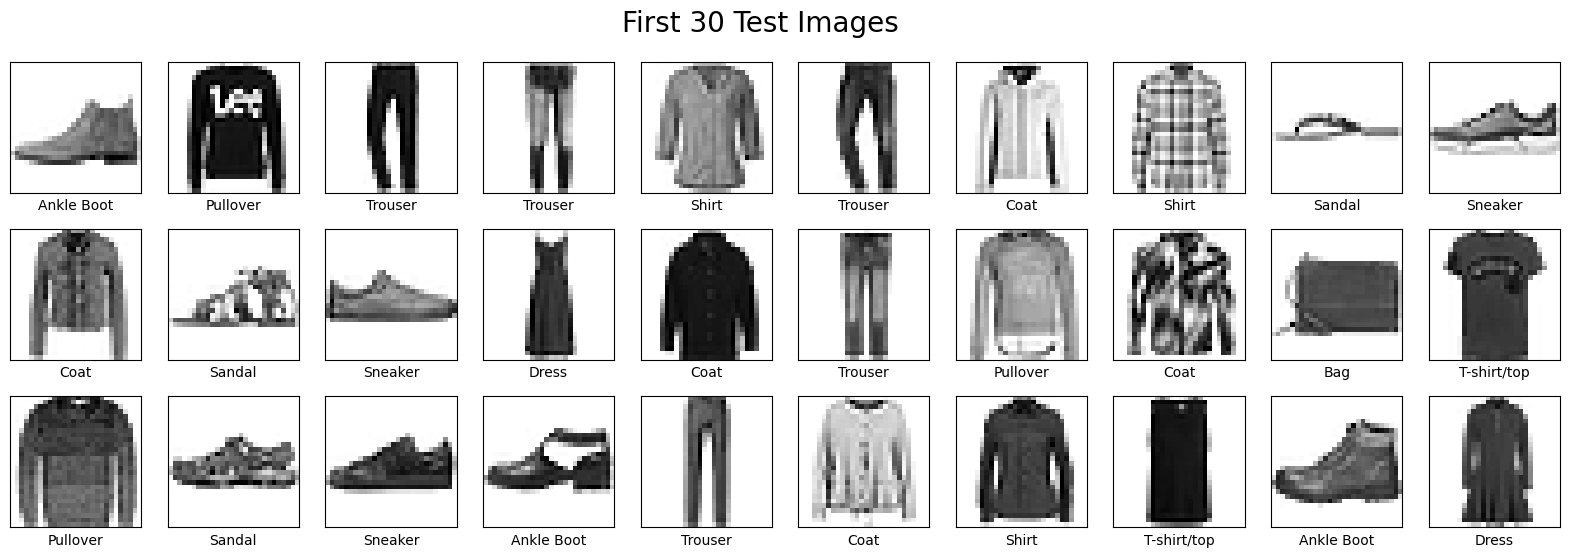

In [8]:
# Display first 30 test images
plt.figure(figsize=(20, 6))
plt.suptitle("First 30 Test Images", fontsize=20)
plt.subplots_adjust(top=0.90)

for i in range(30):
    plt.subplot(3, 10, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(test_images[i], cmap=plt.cm.binary)
    plt.xlabel(labels[test_labels[i]]) 
    
#plt.tight_layout() 
plt.show()

Class           Training Set                                                           Test Set
-----------------------------------------------------------------------------------------------------------------------------
T-shirt/top     Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Trouser         Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Pullover        Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Dress           Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Coat            Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Sandal          Count:  6000, Percentage: 10.0000%                                     Count:  1000, Percentage: 10.0000%
Shirt           Count:  6000, Percentage: 10.0

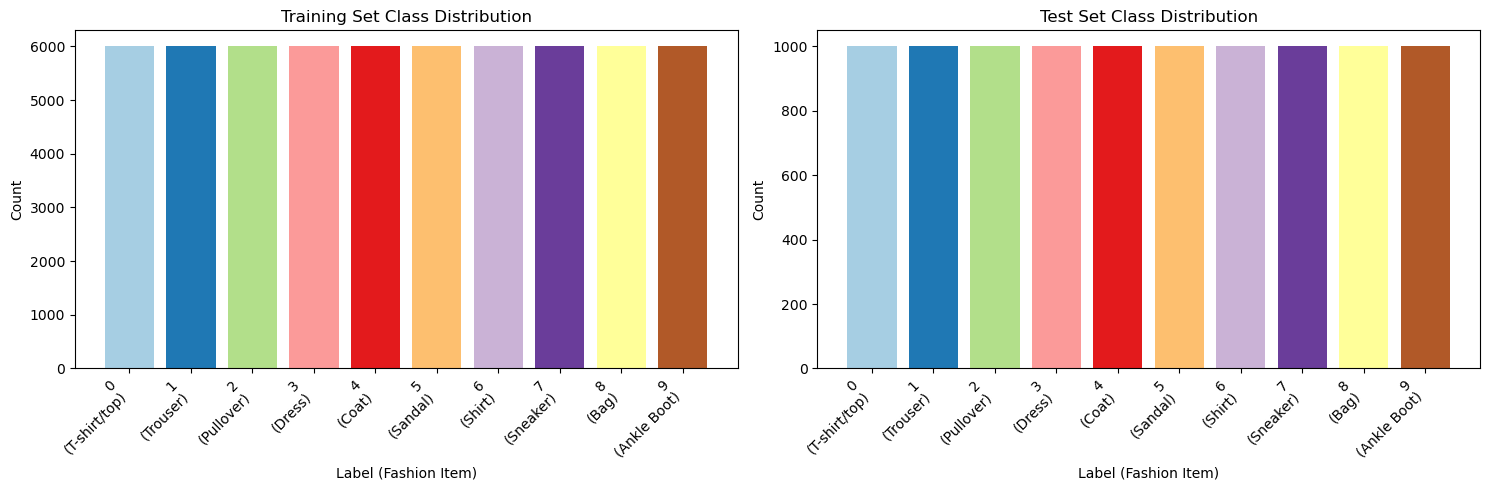

In [9]:
# Display class distribution of the training set and test set
def get_class_distribution_info_1(labels_array, label_names_map, num_classes):
    # Counts the occurrences of each non-negative integer in an array
    class_counts = np.bincount(labels_array, minlength=num_classes)
    total_samples = len(labels_array)
    distribution_info = {}
    
    for i, count in enumerate(class_counts):
        percentage = (count / total_samples) * 100
        distribution_info[label_names_map[i]] = f"Count: {count:>5}, Percentage: {percentage:.4f}%"
    return distribution_info, class_counts

# Get the distributions for training and test sets
train_distribution_info, train_counts_for_plot = get_class_distribution_info_1(train_labels, labels, NUM_CLASSES)
test_distribution_info, test_counts_for_plot = get_class_distribution_info_1(test_labels, labels, NUM_CLASSES)

# Print the class distribution table
print(f"{'Class':<15} {'Training Set':<70} {'Test Set'}")
print("-" * (15 + 70 + 40)) 

# Iterate through sorted keys to ensure consistent order
for label_id in sorted(labels.keys()): 
    label_name = labels[label_id]
    train_info = train_distribution_info.get(label_name, "N/A")
    test_info = test_distribution_info.get(label_name, "N/A")
    print(f"{label_name:<15} {train_info:<70} {test_info}")

# Plot the class distribution
colors = plt.get_cmap('Paired', len(labels))
plt.figure(figsize=(15, 5))

# Training set plot
plt.subplot(1, 2, 1)
bars_train = plt.bar(range(NUM_CLASSES), train_counts_for_plot, color=colors.colors)
plt.title('Training Set Class Distribution')
plt.xlabel('Label (Fashion Item)')
plt.ylabel('Count')
plt.xticks(range(NUM_CLASSES), [f"{i}\n({labels[i]})" for i in range(NUM_CLASSES)], rotation=45, ha='right')
plt.tight_layout()

# Test set plot
plt.subplot(1, 2, 2)
bars_test = plt.bar(range(NUM_CLASSES), test_counts_for_plot, color=colors.colors)
plt.title('Test Set Class Distribution')
plt.xlabel('Label (Fashion Item)')
plt.ylabel('Count')
plt.xticks(range(NUM_CLASSES), [f"{i}\n({labels[i]})" for i in range(NUM_CLASSES)], rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Data Preprocessing

This section addresses any issues which directly impact model performance and stability.

* **Normalization:** Scaling the values to a smaller, standardized range, typically between 0.0 and 1.0. This improves training stability and helps prevent issues with large gradients during optimization.
* **Reshaping:** Neural networks, particularly CNNs, require input data to be in a specific tensor shape.
    - For Feedforward Neural Networks (FNNs), images were flattened from (28, 28) to a 1D vector of (784,).
    - For Convolutional Neural Networks (CNNs), images were reshaped to (28, 28, 1) to explicitly include a single grayscale channel.
* **One-hot encoding:** Converts single integer labels into binary vectors. This avoids implying any ordinal relationship between categories and complements the use of categorical cross-entropy as the loss function.
* **Assign variables in train and test set:** Explicitly assigned to standard variables for train and test set for final model evaluation.
* **Split train set into train and validation set:** A portion of the training data was further split into a dedicated validation set. This allows for continuous monitoring of model performance after each epoch, providing an unbiased estimate of its generalization ability on unseen data throughout the training phase.
* **Display shape of processed data:** To confirm that the data had undergone all necessary preprocessing steps.
* **Display class distribution:** Observe the completeness of the dataset's class representation between training and validation set.

In [10]:
# Normalize the pixel values to the range [0, 1]
train_images = train_images.astype('float32') / 255.0
test_images = test_images.astype('float32') / 255.0

# Reshape the images to have a channel dimension (for CNNs)
train_images = train_images.reshape(-1, IMG_ROWS, IMG_COLS, 1)
test_images = test_images.reshape(-1, IMG_ROWS, IMG_COLS, 1)

# One-hot encode the labels
train_labels = to_categorical(train_labels, num_classes=NUM_CLASSES)
test_labels = to_categorical(test_labels, num_classes=NUM_CLASSES)

print("Shape of training images after reshaping:", train_images.shape)
print("Shape of test images after reshaping:", test_images.shape)
print("Shape of training labels after one-hot encoding:", train_labels.shape)
print("Shape of test labels after one-hot encoding:", test_labels.shape)

Shape of training images after reshaping: (60000, 28, 28, 1)
Shape of test images after reshaping: (10000, 28, 28, 1)
Shape of training labels after one-hot encoding: (60000, 10)
Shape of test labels after one-hot encoding: (10000, 10)


In [11]:
# Assign variables to preprocessed data (train and test)
X = train_images
y = train_labels
X_test = test_images
y_test = test_labels

# Display preprocessed data (train and test)
print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_test:", y_test.shape)

Shape of X: (60000, 28, 28, 1)
Shape of y: (60000, 10)
Shape of X_test: (10000, 28, 28, 1)
Shape of y_test: (10000, 10)


In [12]:
# Split train set into train and validation (train and validation)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Display train and validation shape (train and validation)
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of X_val:", X_val.shape)
print("Shape of y_val:", y_val.shape)

Shape of X_train: (48000, 28, 28, 1)
Shape of y_train: (48000, 10)
Shape of X_val: (12000, 28, 28, 1)
Shape of y_val: (12000, 10)


In [13]:
# Display shape of the processed training, validation and test set 
data_dimensions = [] # Create a list of dictionaries for training, validation and test
data_dimensions.append({
    "Dataset": "Training Set:",
    "Rows": X_train.shape[0],
    "Columns": str(X_train.shape[1:]) 
})
data_dimensions.append({
    "Dataset": "Validation Set:",
    "Rows": X_val.shape[0],
    "Columns": str(X_val.shape[1:])
})
data_dimensions.append({
    "Dataset": "Test Set:",
    "Rows": X_test.shape[0],
    "Columns": str(X_test.shape[1:])
})

# Create a Pandas DataFrame from the list of dictionaries
df_dimensions = pd.DataFrame(data_dimensions)

#df_dimensions
print(df_dimensions.to_string(index=False))

        Dataset  Rows     Columns
  Training Set: 48000 (28, 28, 1)
Validation Set: 12000 (28, 28, 1)
      Test Set: 10000 (28, 28, 1)


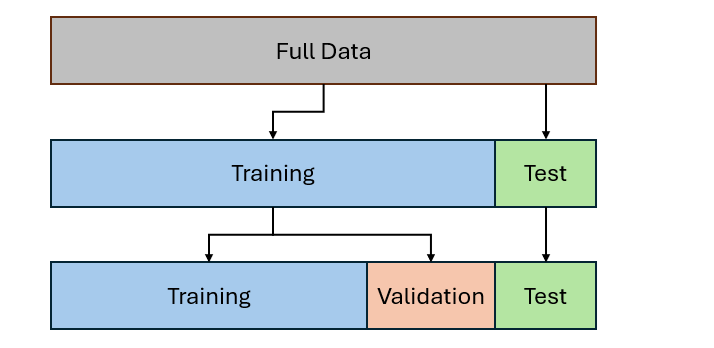

Class           Training Set                                                           Validation Set
-----------------------------------------------------------------------------------------------------------------------------
T-shirt/top     Count:  4798, Percentage: 9.9958%                                      Count:  1202, Percentage: 10.0167%
Trouser         Count:  4781, Percentage: 9.9604%                                      Count:  1219, Percentage: 10.1583%
Pullover        Count:  4795, Percentage: 9.9896%                                      Count:  1205, Percentage: 10.0417%
Dress           Count:  4816, Percentage: 10.0333%                                     Count:  1184, Percentage: 9.8667%
Coat            Count:  4798, Percentage: 9.9958%                                      Count:  1202, Percentage: 10.0167%
Sandal          Count:  4789, Percentage: 9.9771%                                      Count:  1211, Percentage: 10.0917%
Shirt           Count:  4782, Percentage:

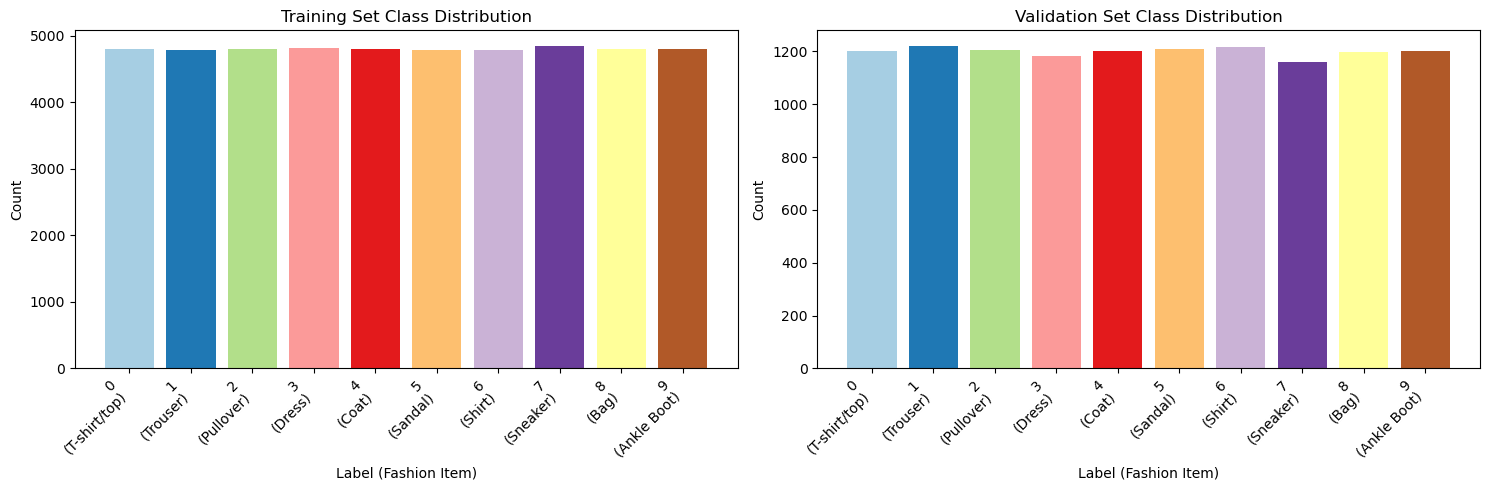

In [14]:
# Display class distribution of the training set and validation set
def get_class_distribution_info_2(labels_one_hot, label_names_map, num_classes):
    # Convert the one-hot encoded labels back into their original integer format
    labels_original = np.argmax(labels_one_hot, axis=1)

    # Counts the occurrences of each non-negative integer in an array
    class_counts = np.bincount(labels_original, minlength=num_classes)
    total_samples = len(labels_original)
    distribution_info = {}
    
    for i, count in enumerate(class_counts):
        percentage = (count / total_samples) * 100
        distribution_info[label_names_map[i]] = f"Count: {count:>5}, Percentage: {percentage:.4f}%"
    return distribution_info, class_counts

# Get the distributions for training and validation sets
train_distribution_info, train_counts_for_plot = get_class_distribution_info_2(y_train, labels, NUM_CLASSES)
val_distribution_info, val_counts_for_plot = get_class_distribution_info_2(y_val, labels, NUM_CLASSES)

# Print the class distribution table
print(f"{'Class':<15} {'Training Set':<70} {'Validation Set'}")
print("-" * (15 + 70 + 40))

# Iterate through sorted keys to ensure consistent order
for label_id in sorted(labels.keys()):
    label_name = labels[label_id]
    train_info = train_distribution_info.get(label_name, "N/A")
    val_info = val_distribution_info.get(label_name, "N/A")
    print(f"{label_name:<15} {train_info:<70} {val_info}")

# Plot the class distribution 
colors = plt.get_cmap('Paired', len(labels))
plt.figure(figsize=(15, 5))

# Training set plot
plt.subplot(1, 2, 1)
bars_train = plt.bar(range(NUM_CLASSES), train_counts_for_plot, color=colors.colors)
plt.title('Training Set Class Distribution')
plt.xlabel('Label (Fashion Item)')
plt.ylabel('Count')
plt.xticks(range(NUM_CLASSES), [f"{i}\n({labels[i]})" for i in range(NUM_CLASSES)], rotation=45, ha='right')
plt.tight_layout()

# Validation set plot
plt.subplot(1, 2, 2)
bars_val = plt.bar(range(NUM_CLASSES), val_counts_for_plot, color=colors.colors)
plt.title('Validation Set Class Distribution')
plt.xlabel('Label (Fashion Item)')
plt.ylabel('Count')
plt.xticks(range(NUM_CLASSES), [f"{i}\n({labels[i]})" for i in range(NUM_CLASSES)], rotation=45, ha='right')
plt.tight_layout()

plt.show()

### Model Development and Evaluation

This section details the development and evaluation of the Convolutional Neural Network architecture. The experiments were designed to systematically investigated how network depth, regularization (Dropout), and hyperparameter tuning impacted model performance and generalization.

**Models Developed:**

* **Model 1. Baseline CNN (2 Blocks):** Established a foundational performance benchmark.
* **Model 2. Dropout Regularization:** Assessed the effectiveness of Dropout on the baseline CNN.
* **Model 3. Increased Depth:** Investigated the impact of a deeper 3-block CNN architecture.
* **Model 4. Hyperparameter Tuning (Learning Rate):** Optimized the 3-block CNN by tuning the learning rate.

**Evaluation Protocol:**

For each model, the following sequential steps were performed:

* **A) Model Construction & Inspection:** The architecture of each model was defined, followed by an inspection of its layer composition and parameter count.
* **B) Model plot Visualization:** Plots a schematic diagram to provide a clear and intuitive visual representation of its architecture. 
* **C) Model Training:** Models were trained on the designated training dataset, utilizing Adam optimizer and categorical cross-entropy loss.
* **D) Analysis of Training and Validation Performance:** Continuous monitoring of training and validation metrics allowed for real-time assessment of the model's learning curve and its ability to generalize to unseen data during the training phase.
* **E) Assessment of Test Set Performance:** To obtain an unbiased measure of the model's ultimate generalization ability, its performance (loss and accuracy) was evaluated on a completely unseen test dataset.
* **F) Detailed Performance Diagnostics:** To gain granular insights into model behavior, a confusion matrix was generated to visualize classification accuracy per class, complemented by a classification report detailing precision, recall, and F1-score for each category.

#### Model 1. Baseline CNN (2 Blocks)
Established a foundational performance benchmark.

In [15]:
# 1A) Model Construction - Baseline Convolutional Neural Networks (CNN) (2 Convolutional Blocks)
model_CNN_Baseline = Sequential()

# Input Layer (28x28 pixels, 1 channel for grayscale)
model_CNN_Baseline.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))

# First Convolutional Block
model_CNN_Baseline.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding= 'valid', 
                              activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Baseline.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid'))

# Second Convolutional Block 
model_CNN_Baseline.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding= 'valid', 
                              activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Baseline.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid'))

# Flatten Layer to Convert the 3D feature maps into a 1D vector for Dense layers
model_CNN_Baseline.add(Flatten())

# Dense Hidden Layer: Standard fully connected layer
model_CNN_Baseline.add(Dense(units=128, activation='relu'))

# Output Layer
model_CNN_Baseline.add(Dense(units=NUM_CLASSES, activation='softmax'))

# Compile the model and its learning process
model_CNN_Baseline.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Inspect model architecture
model_CNN_Baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

##### 1B) Model plot Visualization - Baseline Convolutional Neural Networks (CNN) (2 Convolutional Blocks)

This diagram illustrates the sequential arrangement of layers, the transformation of data through each stage (showing input and output shapes), and the overall flow of information within the network

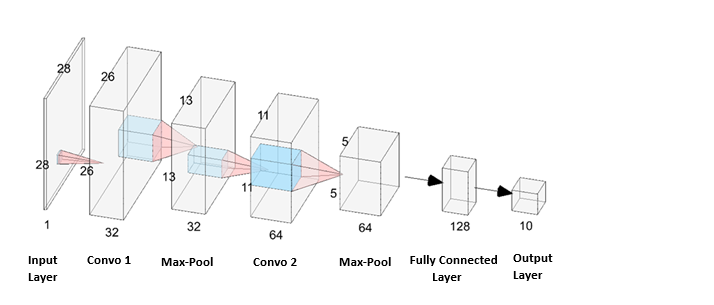

In [16]:
 # 1C) Model training
print("Starting model training...")
history_CNN_Baseline = model_CNN_Baseline.fit(X_train, y_train,
                                              epochs=NO_EPOCHS,
                                              batch_size=BATCH_SIZE,
                                              validation_data=(X_val, y_val),
                                              verbose=1)
print("Model training finished.")

Starting model training...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7490 - loss: 0.7114 - val_accuracy: 0.8718 - val_loss: 0.3521
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8823 - loss: 0.3262 - val_accuracy: 0.8842 - val_loss: 0.3182
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9012 - loss: 0.2742 - val_accuracy: 0.8945 - val_loss: 0.2901
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9124 - loss: 0.2415 - val_accuracy: 0.9004 - val_loss: 0.2793
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9192 - loss: 0.2219 - val_accuracy: 0.9008 - val_loss: 0.2751
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9285 - loss: 0.2005 - val_accuracy: 0.9043 - val_loss: 0.2697
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9373 - loss: 0.1735 - val_accuracy: 0.9034 - val_loss: 0.2686
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9402 - loss

In [17]:
# 1D) Evaluate train and validation accuracy and loss 
def create_trace(x, y, ylabel, color):
    trace = go.Scatter(x=x,y=y,
                       name=ylabel,
                       marker=dict(color=color),
                       mode="lines+markers", 
                       text=[f"Epoch {epoch}<br>{ylabel}: {value:.4f}" for epoch, value in zip(x, y)], # Custom hover text
                       hoverinfo='text' # Show only custom text on hover
                      )
    return trace

def plot_accuracy_and_loss_plotly(history_object):
    hist = history_object.history
    acc = hist['accuracy']
    val_acc = hist['val_accuracy']
    loss = hist['loss']
    val_loss = hist['val_loss']
    
    epochs = list(range(1, len(acc) + 1))
    
    trace_ta = create_trace(epochs, acc, "Training Accuracy", "#006400") # Green
    trace_va = create_trace(epochs, val_acc, "Validation Accuracy", "#B3000C") # Red
    trace_tl = create_trace(epochs, loss, "Training Loss", "#305CDE") # Blue
    trace_vl = create_trace(epochs, val_loss, "Validation Loss", "#BE93E4") # Purple
   
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Training and Validation Accuracy', 'Training and Validation Loss'))
    
    # Add traces to the first subplot (Accuracy)
    fig.add_trace(trace_ta, row=1, col=1)
    fig.add_trace(trace_va, row=1, col=1)
    
    # Add traces to the second subplot (Loss)
    fig.add_trace(trace_tl, row=1, col=2)
    fig.add_trace(trace_vl, row=1, col=2)
    
    # Update layout for x-axes
    fig.update_xaxes(title_text='Epoch', row=1, col=1)
    fig.update_xaxes(title_text='Epoch', row=1, col=2)
    
    # Update layout for y-axes
    fig.update_yaxes(title_text='Accuracy', range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text='Loss', row=1, col=2) 
    
    fig.update_layout(height=500, width=1000, title_text="Model Training History", showlegend=True)
    fig.show()

plot_accuracy_and_loss_plotly(history_CNN_Baseline)

The model exhibits signs of overfitting, with a very high training accuracy that contrasts with a fluctuating and plateauing validation accuracy. This is further confirmed by the large divergence between the steadily decreasing training loss and the increasing validation loss after a few epochs.

In [18]:
# 1E) Evaluate Test prediction accuracy and loss
print("Evaluating model_CNN_Baseline on the test set:")
test_loss_CNN_Baseline, test_accuracy_CNN_Baseline = model_CNN_Baseline.evaluate(X_test, y_test, verbose=1) 
print(f"Test Accuracy: {test_accuracy_CNN_Baseline:.4f}")
print(f"Test Loss: {test_loss_CNN_Baseline:.4f}")

Evaluating model_CNN_Baseline on the test set:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9108 - loss: 0.8398
Test Accuracy: 0.9098
Test Loss: 0.8251


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


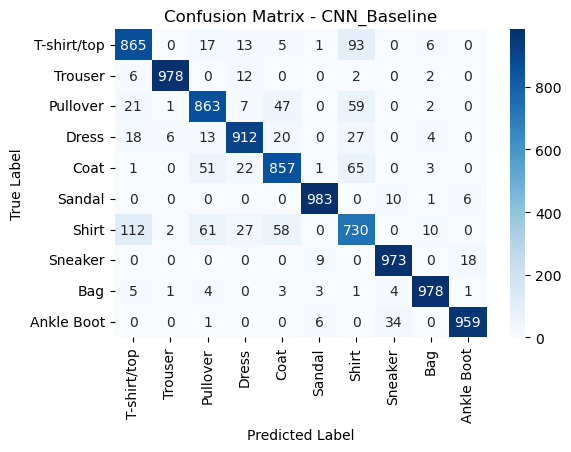


Confusion Matrix - CNN_Baseline (Raw):
[[865   0  17  13   5   1  93   0   6   0]
 [  6 978   0  12   0   0   2   0   2   0]
 [ 21   1 863   7  47   0  59   0   2   0]
 [ 18   6  13 912  20   0  27   0   4   0]
 [  1   0  51  22 857   1  65   0   3   0]
 [  0   0   0   0   0 983   0  10   1   6]
 [112   2  61  27  58   0 730   0  10   0]
 [  0   0   0   0   0   9   0 973   0  18]
 [  5   1   4   0   3   3   1   4 978   1]
 [  0   0   1   0   0   6   0  34   0 959]]

Correct predicted classes: 9098 (90.98%)
Incorrect predicted classes: 902 (9.02%)

Classification Report - CNN_Baseline
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.86      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.86      0.86      1000
       Dress       0.92      0.91      0.92      1000
        Coat       0.87      0.86      0.86      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.75      

In [19]:
# 1F) Evaluate confusion matrix and Classification Report

# Get predictions from the model
y_pred_test_CNN_Baseline = model_CNN_Baseline.predict(X_test)

# Convert predicted labels to class labels 
y_pred_labels_CNN_Baseline = np.argmax(y_pred_test_CNN_Baseline, axis=1) 

# Convert true one-hot encoded labels back to integer class labels
y_true_labels_CNN_Baseline = np.argmax(y_test, axis=1)

# Generate the Confusion Matrix
conf_matrix_CNN_Baseline = confusion_matrix(y_true_labels_CNN_Baseline, y_pred_labels_CNN_Baseline)

# Display the confusion matrix 
plt.figure(figsize=(6, 4)) 
sns.heatmap(conf_matrix_CNN_Baseline, annot=True, fmt='d', cmap='Blues',
            xticklabels=[labels[i] for i in range(NUM_CLASSES)],
            yticklabels=[labels[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN_Baseline')
plt.show()

# Display the confusion matrix raw version
print("\nConfusion Matrix - CNN_Baseline (Raw):")
print(conf_matrix_CNN_Baseline)

# Display number of correct and incorrect predictions.
correct_prediction = np.where(y_true_labels_CNN_Baseline == y_pred_labels_CNN_Baseline)[0]
incorrect_prediction = np.where(y_true_labels_CNN_Baseline != y_pred_labels_CNN_Baseline)[0]

total_prediction = correct_prediction.shape[0] + incorrect_prediction.shape[0]
correct_percentage = (correct_prediction.shape[0] / total_prediction) * 100
incorrect_percentage = (incorrect_prediction.shape[0] / total_prediction) * 100

print("\nCorrect predicted classes:", correct_prediction.shape[0], f"({correct_percentage:.2f}%)")
print("Incorrect predicted classes:", incorrect_prediction.shape[0], f"({incorrect_percentage:.2f}%)")

# Display the Classification Report
print("\nClassification Report - CNN_Baseline")
class_report_CNN_Baseline = classification_report(y_true_labels_CNN_Baseline, y_pred_labels_CNN_Baseline, target_names=[labels[i] for i in range(NUM_CLASSES)])
print(class_report_CNN_Baseline)

#### Model 2. Dropout Regularization
Assessed the effectiveness of Dropout on the baseline CNN.

In [20]:
# 2A) Model Construction - Convolutional Neural Networks (CNN) (2 Convolutional Blocks with Dropout)
model_CNN_Dropout = Sequential()  

# Input Layer (28x28 pixels, 1 channel for grayscale)
model_CNN_Dropout.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))

# First Convolutional Block 
model_CNN_Dropout.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                             activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Dropout.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Dropout.add(Dropout(0.25)) 

# Second Convolutional Block 
model_CNN_Dropout.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                             activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Dropout.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Dropout.add(Dropout(0.25)) 

# Flatten Layer to Convert the 3D feature maps into a 1D vector for Dense layers
model_CNN_Dropout.add(Flatten())

# Dense Hidden Layer: Standard fully connected layer
model_CNN_Dropout.add(Dense(128, activation='relu'))
model_CNN_Dropout.add(Dropout(0.5)) # Dropout for the dense hidden layer (often higher for Dense layers)

# Output Layer
model_CNN_Dropout.add(Dense(NUM_CLASSES, activation='softmax'))

# Compile the model and its learning process
model_CNN_Dropout.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Inspect model architecture
model_CNN_Dropout.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

##### 2B) Model plot Visualization -  Convolutional Neural Networks (CNN) (2 Convolutional Blocks with Dropout)

This diagram illustrates the sequential arrangement of layers, the transformation of data through each stage (showing input and output shapes), and the overall flow of information within the network

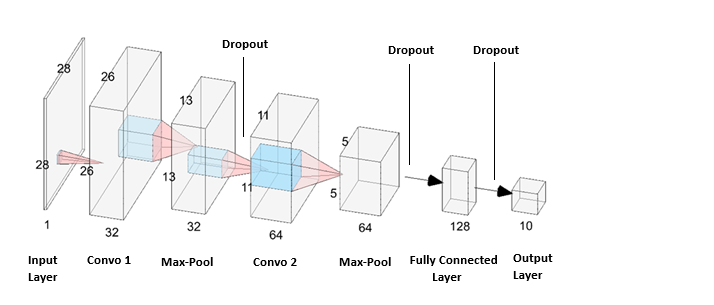

In [21]:
# 2C) Model training
print("Starting model training...")
history_CNN_Dropout = model_CNN_Dropout.fit(X_train, y_train,
                                            epochs=NO_EPOCHS,
                                            batch_size=BATCH_SIZE,
                                            validation_data=(X_val, y_val),
                                            verbose=1)
print("Model training finished.")

Starting model training...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.5764 - loss: 1.2493 - val_accuracy: 0.8143 - val_loss: 0.4880
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7957 - loss: 0.5527 - val_accuracy: 0.8456 - val_loss: 0.4237
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8258 - loss: 0.4774 - val_accuracy: 0.8725 - val_loss: 0.3516
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8420 - loss: 0.4346 - val_accuracy: 0.8725 - val_loss: 0.3400
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8546 - loss: 0.3985 - val_accuracy: 0.8842 - val_loss: 0.3136
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8662 - loss: 0.3685 - val_accuracy: 0.8916 - val_loss: 0.2972
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8709 - loss: 0.3586 - val_accuracy: 0.8932 - val_loss: 0.2914
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8762 - los

In [22]:
# 2D) Evaluate train and validation accuracy and loss 
def create_trace(x, y, ylabel, color):
    trace = go.Scatter(x=x,y=y,
                       name=ylabel,
                       marker=dict(color=color),
                       mode="lines+markers", 
                       text=[f"Epoch {epoch}<br>{ylabel}: {value:.4f}" for epoch, value in zip(x, y)], # Custom hover text
                       hoverinfo='text' # Show only custom text on hover
                      )
    return trace

def plot_accuracy_and_loss_plotly(history_object):
    hist = history_object.history
    acc = hist['accuracy']
    val_acc = hist['val_accuracy']
    loss = hist['loss']
    val_loss = hist['val_loss']
    
    epochs = list(range(1, len(acc) + 1))
    
    trace_ta = create_trace(epochs, acc, "Training Accuracy", "#006400") # Green
    trace_va = create_trace(epochs, val_acc, "Validation Accuracy", "#B3000C") # Red
    trace_tl = create_trace(epochs, loss, "Training Loss", "#305CDE") # Blue
    trace_vl = create_trace(epochs, val_loss, "Validation Loss", "#BE93E4") # Purple
   
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Training and Validation Accuracy', 'Training and Validation Loss'))
    
    # Add traces to the first subplot (Accuracy)
    fig.add_trace(trace_ta, row=1, col=1)
    fig.add_trace(trace_va, row=1, col=1)
    
    # Add traces to the second subplot (Loss)
    fig.add_trace(trace_tl, row=1, col=2)
    fig.add_trace(trace_vl, row=1, col=2)
    
    # Update layout for x-axes
    fig.update_xaxes(title_text='Epoch', row=1, col=1)
    fig.update_xaxes(title_text='Epoch', row=1, col=2)
    
    # Update layout for y-axes
    fig.update_yaxes(title_text='Accuracy', range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text='Loss', row=1, col=2) 
    
    fig.update_layout(height=500, width=1000, title_text="Model Training History", showlegend=True)
    fig.show()

plot_accuracy_and_loss_plotly(history_CNN_Dropout)

With Dropout implemented, the Training-Validation gap significantly narrowed for both Accuracy and Loss, demonstrating a successful reduction in overfitting. The model is now generalizing better.

In [23]:
# 2E) Evaluate Test prediction accuracy and loss
print("Evaluating model CNN_Dropout on the test set:")
test_loss_CNN_Dropout, test_accuracy_CNN_Dropout = model_CNN_Dropout.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy_CNN_Dropout:.4f}")
print(f"Test Loss: {test_loss_CNN_Dropout:.4f}")

Evaluating model CNN_Dropout on the test set:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9179 - loss: 0.2490
Test Accuracy: 0.9207
Test Loss: 0.2299


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


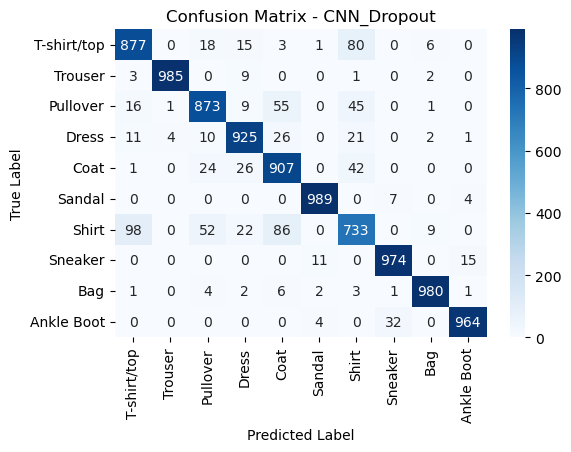


Confusion Matrix - CNN_Dropout (Raw):
[[877   0  18  15   3   1  80   0   6   0]
 [  3 985   0   9   0   0   1   0   2   0]
 [ 16   1 873   9  55   0  45   0   1   0]
 [ 11   4  10 925  26   0  21   0   2   1]
 [  1   0  24  26 907   0  42   0   0   0]
 [  0   0   0   0   0 989   0   7   0   4]
 [ 98   0  52  22  86   0 733   0   9   0]
 [  0   0   0   0   0  11   0 974   0  15]
 [  1   0   4   2   6   2   3   1 980   1]
 [  0   0   0   0   0   4   0  32   0 964]]

Correct predicted classes: 9207 (92.07%)
Incorrect predicted classes: 793 (7.93%)

Classification Report: CNN_Dropout
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.88      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.89      0.87      0.88      1000
       Dress       0.92      0.93      0.92      1000
        Coat       0.84      0.91      0.87      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.79      0.7

In [24]:
# 2F) Evaluate confusion matrix and Classification Report

# Get predictions from the model
y_pred_test_CNN_Dropout = model_CNN_Dropout.predict(X_test)

# Convert predicted labels to class labels 
y_pred_labels_CNN_Dropout = np.argmax(y_pred_test_CNN_Dropout, axis=1) 

# Convert true one-hot encoded labels back to integer class labels
y_true_labels_CNN_Dropout = np.argmax(y_test, axis=1)

# Generate the Confusion Matrix
conf_matrix_CNN_Dropout = confusion_matrix(y_true_labels_CNN_Dropout, y_pred_labels_CNN_Dropout)

# Display the confusion matrix 
plt.figure(figsize=(6, 4)) 
sns.heatmap(conf_matrix_CNN_Dropout, annot=True, fmt='d', cmap='Blues',
            xticklabels=[labels[i] for i in range(NUM_CLASSES)],
            yticklabels=[labels[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN_Dropout')
plt.show()

# Display the confusion matrix raw version
print("\nConfusion Matrix - CNN_Dropout (Raw):")
print(conf_matrix_CNN_Dropout)

# Display number of correct and incorrect predictions.
correct_prediction = np.where(y_true_labels_CNN_Dropout == y_pred_labels_CNN_Dropout)[0]
incorrect_prediction = np.where(y_true_labels_CNN_Dropout != y_pred_labels_CNN_Dropout)[0]

total_prediction = correct_prediction.shape[0] + incorrect_prediction.shape[0]
correct_percentage = (correct_prediction.shape[0] / total_prediction) * 100
incorrect_percentage = (incorrect_prediction.shape[0] / total_prediction) * 100

print("\nCorrect predicted classes:", correct_prediction.shape[0], f"({correct_percentage:.2f}%)")
print("Incorrect predicted classes:", incorrect_prediction.shape[0], f"({incorrect_percentage:.2f}%)")

# Display the Classification Report
print("\nClassification Report: CNN_Dropout")
class_report_CNN_Dropout = classification_report(y_true_labels_CNN_Dropout, y_pred_labels_CNN_Dropout, target_names=[labels[i] for i in range(NUM_CLASSES)])
print(class_report_CNN_Dropout)

#### Model 3. Increased Depth

Investigated the impact of a deeper 3-block CNN architecture.

In [25]:
# 3A) Model Construction - Convolutional Neural Networks (CNN) (3 Convolutional Blocks with Dropout)
model_CNN_Deeper = Sequential() 

# Input Layer (28x28 pixels, 1 channel for grayscale)
model_CNN_Deeper.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))

# First Convolutional Block 
model_CNN_Deeper.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                            activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Deeper.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Deeper.add(Dropout(0.25)) 

# Second Convolutional Block 
model_CNN_Deeper.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                            activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Deeper.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Deeper.add(Dropout(0.25)) 

# Third Convolutional Block 
model_CNN_Deeper.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                            activation='relu', kernel_initializer= 'he_normal'))
# Omitting MaxPooling2D to preserve more spatial detail before flattening.
model_CNN_Deeper.add(Dropout(0.25)) 

# Flatten Layer to Convert the 3D feature maps into a 1D vector for Dense layers
model_CNN_Deeper.add(Flatten())

# Dense Hidden Layer: Standard fully connected layer
model_CNN_Deeper.add(Dense(128, activation='relu'))
model_CNN_Deeper.add(Dropout(0.5))

# Output Layer
model_CNN_Deeper.add(Dense(NUM_CLASSES, activation='softmax'))

# Compile the model and its learning proces
model_CNN_Deeper.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Inspect model architecture
model_CNN_Deeper.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

##### 3B) Model plot Visualization - Convolutional Neural Networks (CNN) (3 Convolutional Blocks with Dropout)

This diagram illustrates the sequential arrangement of layers, the transformation of data through each stage (showing input and output shapes), and the overall flow of information within the network

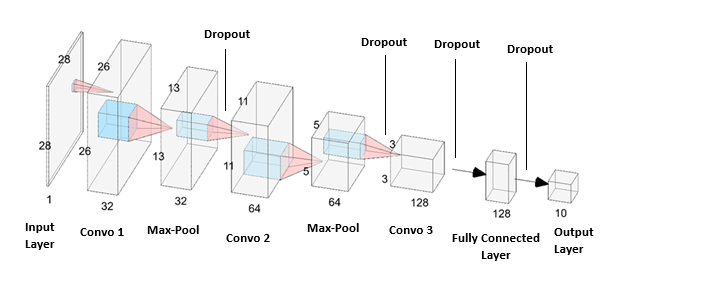

In [26]:
# 3C) Model training
print("Starting model training...")
history_CNN_Deeper = model_CNN_Deeper.fit(X_train, y_train,
                                          epochs=NO_EPOCHS,
                                          batch_size=BATCH_SIZE,
                                          validation_data=(X_val, y_val),
                                          verbose=1)
print("Model training finished.")

Starting model training...
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5361 - loss: 1.3186 - val_accuracy: 0.8092 - val_loss: 0.5234
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7883 - loss: 0.5695 - val_accuracy: 0.8402 - val_loss: 0.4401
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8214 - loss: 0.4787 - val_accuracy: 0.8627 - val_loss: 0.3747
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8415 - loss: 0.4298 - val_accuracy: 0.8767 - val_loss: 0.3341
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8553 - loss: 0.3907 - val_accuracy: 0.8842 - val_loss: 0.3181
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8644 - loss: 0.3679 - val_accuracy: 0.8908 - val_loss: 0.2913
Epoch 7/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8755 - loss: 0.3423 - val_accuracy: 0.8921 - val_loss: 0.2919
Epoch 8/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.881

In [27]:
# 3D) Evaluate train and validation accuracy and loss 
def create_trace(x, y, ylabel, color):
    trace = go.Scatter(x=x,y=y,
                       name=ylabel,
                       marker=dict(color=color),
                       mode="lines+markers", 
                       text=[f"Epoch {epoch}<br>{ylabel}: {value:.4f}" for epoch, value in zip(x, y)], # Custom hover text
                       hoverinfo='text' # Show only custom text on hover
                      )
    return trace

def plot_accuracy_and_loss_plotly(history_object):
    hist = history_object.history
    acc = hist['accuracy']
    val_acc = hist['val_accuracy']
    loss = hist['loss']
    val_loss = hist['val_loss']
    
    epochs = list(range(1, len(acc) + 1))
    
    trace_ta = create_trace(epochs, acc, "Training Accuracy", "#006400") # Green
    trace_va = create_trace(epochs, val_acc, "Validation Accuracy", "#B3000C") # Red
    trace_tl = create_trace(epochs, loss, "Training Loss", "#305CDE") # Blue
    trace_vl = create_trace(epochs, val_loss, "Validation Loss", "#BE93E4") # Purple
   
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Training and Validation Accuracy', 'Training and Validation Loss'))
    
    # Add traces to the first subplot (Accuracy)
    fig.add_trace(trace_ta, row=1, col=1)
    fig.add_trace(trace_va, row=1, col=1)
    
    # Add traces to the second subplot (Loss)
    fig.add_trace(trace_tl, row=1, col=2)
    fig.add_trace(trace_vl, row=1, col=2)
    
    # Update layout for x-axes
    fig.update_xaxes(title_text='Epoch', row=1, col=1)
    fig.update_xaxes(title_text='Epoch', row=1, col=2)
    
    # Update layout for y-axes
    fig.update_yaxes(title_text='Accuracy', range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text='Loss', row=1, col=2) 
    
    fig.update_layout(height=500, width=1000, title_text="Model Training History", showlegend=True)
    fig.show()

plot_accuracy_and_loss_plotly(history_CNN_Deeper)

The validation loss began to diverge from the training loss after a few epoch, possibly suggesting a compromise in generalization.

In [28]:
# 3E) Evaluate Test prediction accuracy and loss
print("Evaluating model CNN_Deeper on the test set:")
test_loss_CNN_Deeper, test_accuracy_CNN_Deeper = model_CNN_Deeper.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy_CNN_Deeper:.4f}")
print(f"Test Loss: {test_loss_CNN_Deeper:.4f}")

Evaluating model CNN_Deeper on the test set:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9171 - loss: 0.2535
Test Accuracy: 0.9175
Test Loss: 0.2413


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


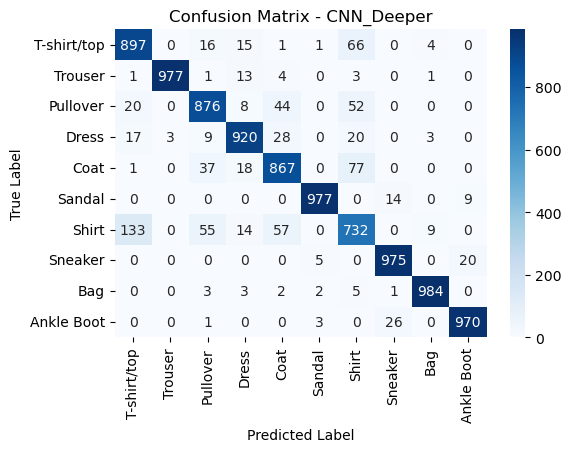


Confusion Matrix - CNN_Deeper (Raw):
[[897   0  16  15   1   1  66   0   4   0]
 [  1 977   1  13   4   0   3   0   1   0]
 [ 20   0 876   8  44   0  52   0   0   0]
 [ 17   3   9 920  28   0  20   0   3   0]
 [  1   0  37  18 867   0  77   0   0   0]
 [  0   0   0   0   0 977   0  14   0   9]
 [133   0  55  14  57   0 732   0   9   0]
 [  0   0   0   0   0   5   0 975   0  20]
 [  0   0   3   3   2   2   5   1 984   0]
 [  0   0   1   0   0   3   0  26   0 970]]

Correct predicted classes: 9175 (91.75%)
Incorrect predicted classes: 825 (8.25%)

Classification Report: CNN_Deeper
              precision    recall  f1-score   support

 T-shirt/top       0.84      0.90      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.88      0.88      0.88      1000
       Dress       0.93      0.92      0.92      1000
        Coat       0.86      0.87      0.87      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.77      0.73 

In [29]:
# 3F) Evaluate confusion matrix and Classification Report

# Get predictions from the model
y_pred_test_CNN_Deeper = model_CNN_Deeper.predict(X_test)

# Convert predicted labels to class labels 
y_pred_labels_CNN_Deeper = np.argmax(y_pred_test_CNN_Deeper, axis=1) 

# Convert true one-hot encoded labels back to integer class labels
y_true_labels_CNN_Deeper = np.argmax(y_test, axis=1)

# Generate the Confusion Matrix
conf_matrix_CNN_Deeper = confusion_matrix(y_true_labels_CNN_Deeper, y_pred_labels_CNN_Deeper)

# Display the confusion matrix 
plt.figure(figsize=(6, 4)) 
sns.heatmap(conf_matrix_CNN_Deeper, annot=True, fmt='d', cmap='Blues',
            xticklabels=[labels[i] for i in range(NUM_CLASSES)],
            yticklabels=[labels[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN_Deeper')
plt.show()

# Display the confusion matrix raw version
print("\nConfusion Matrix - CNN_Deeper (Raw):")
print(conf_matrix_CNN_Deeper)

# Display number of correct and incorrect predictions.
correct_prediction = np.where(y_true_labels_CNN_Deeper == y_pred_labels_CNN_Deeper)[0]
incorrect_prediction = np.where(y_true_labels_CNN_Deeper != y_pred_labels_CNN_Deeper)[0]

total_prediction = correct_prediction.shape[0] + incorrect_prediction.shape[0]
correct_percentage = (correct_prediction.shape[0] / total_prediction) * 100
incorrect_percentage = (incorrect_prediction.shape[0] / total_prediction) * 100

print("\nCorrect predicted classes:", correct_prediction.shape[0], f"({correct_percentage:.2f}%)")
print("Incorrect predicted classes:", incorrect_prediction.shape[0], f"({incorrect_percentage:.2f}%)")

# Display the Classification Report
print("\nClassification Report: CNN_Deeper")
class_report_CNN_Deeper = classification_report(y_true_labels_CNN_Deeper, y_pred_labels_CNN_Deeper, target_names=[labels[i] for i in range(NUM_CLASSES)])
print(class_report_CNN_Deeper)

#### Model 4. Hyperparameter Tuning (Learning Rate)

Optimized the 3-block CNN by tuning the learning rate.

In [30]:
# 4A) Model Construction - Convolutional Neural Networks (CNN) (3 Convolutional Blocks with Dropout & Tuned Learning Rate)
model_CNN_Tuned = Sequential() 

# Input Layer (28x28 pixels, 1 channel for grayscale)
model_CNN_Tuned.add(Input(shape=(IMG_ROWS, IMG_COLS, 1)))

# First Convolutional Block 
model_CNN_Tuned.add(Conv2D(filters=32, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                                activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Tuned.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Tuned.add(Dropout(0.25)) 

# Second Convolutional Block 
model_CNN_Tuned.add(Conv2D(filters=64, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                                activation='relu', kernel_initializer= 'he_normal'))
model_CNN_Tuned.add(MaxPooling2D(pool_size=(2, 2), strides=(2,2), padding= 'valid')) 
model_CNN_Tuned.add(Dropout(0.25)) 

# Third Convolutional Block 
model_CNN_Tuned.add(Conv2D(filters=128, kernel_size=(3, 3), strides=(1, 1), padding= 'valid',
                                activation='relu', kernel_initializer= 'he_normal'))
# Omitting MaxPooling2D here to preserve more spatial detail before flattening. 
model_CNN_Tuned.add(Dropout(0.25)) 

# Flatten Layer to Convert the 3D feature maps into a 1D vector for Dense layers
model_CNN_Tuned.add(Flatten())

# Dense Hidden Layer: Standard fully connected layer
model_CNN_Tuned.add(Dense(128, activation='relu'))
model_CNN_Tuned.add(Dropout(0.5))

# Output Layer
model_CNN_Tuned.add(Dense(NUM_CLASSES, activation='softmax'))

# ExponentialDecay learning rate schedule setup 
initial_learning_rate = 0.001
decay_steps=1000
decay_rate=0.85

lr_schedule = ExponentialDecay(
    initial_learning_rate=initial_learning_rate,
    decay_steps=decay_steps,
    decay_rate=decay_rate,
    staircase=False,
    name="ExponentialDecay")

optimizer = Adam(learning_rate=lr_schedule)

# Compile the model and its learning process
model_CNN_Tuned.compile(optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"])

# Inspect model architecture
model_CNN_Tuned.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241,546 (943.54 KB)

 Trainable params: 241,546 (943.54 KB)

 Non-trainable params: 0 (0.00 B)

##### 4b) Model plot Visualization - Convolutional Neural Networks (CNN) (3 Convolutional Blocks with Dropout & Tuned Learning Rate)

 This architecture is structurally identical to Model 3.

This diagram illustrates the sequential arrangement of layers, the transformation of data through each stage (showing input and output shapes), and the overall flow of information within the network

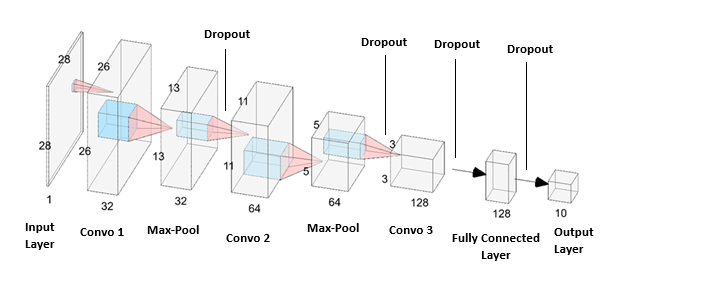

In [31]:
# 4C) Model training

# Custom Callback function 
class LRHistory(tf.keras.callbacks.Callback):
    def __init__(self):
        super().__init__()
        self.lrs = []
        
    def on_epoch_begin(self, epoch, logs=None):
        opt = self.model.optimizer
        if callable(opt.learning_rate):
            lr = opt.learning_rate(opt.iterations)
        else:
            lr = opt.learning_rate
        lr_value = tf.keras.backend.get_value(lr)
        self.lrs.append(lr_value)
        print(f"Epoch {epoch+1}: learning rate = {lr_value:.6f}")
    
# Create an instance of the custom callback
lr_logger = LRHistory()

print("Starting model training...")
history_CNN_Tuned = model_CNN_Tuned.fit(X_train, y_train,
                                        epochs=NO_EPOCHS,
                                        batch_size=BATCH_SIZE,
                                        validation_data=(X_val, y_val),
                                        verbose=1,
                                        callbacks=[lr_logger])
print("Model training finished.")

Starting model training...
Epoch 1: learning rate = 0.001000
Epoch 1/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.5571 - loss: 1.2517 - val_accuracy: 0.8203 - val_loss: 0.5035
Epoch 2: learning rate = 0.000941
Epoch 2/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7889 - loss: 0.5692 - val_accuracy: 0.8422 - val_loss: 0.4238
Epoch 3: learning rate = 0.000885
Epoch 3/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8283 - loss: 0.4748 - val_accuracy: 0.8732 - val_loss: 0.3549
Epoch 4: learning rate = 0.000833
Epoch 4/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8482 - loss: 0.4179 - val_accuracy: 0.8811 - val_loss: 0.3235
Epoch 5: learning rate = 0.000784
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8621 - loss: 0.3855 - val_accuracy: 0.8869 - val_loss: 0.3101
Epoch 6: learning rate = 0.000737
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8684 - loss: 0.3623 - val_accuracy: 0.8942 - val_loss: 0.

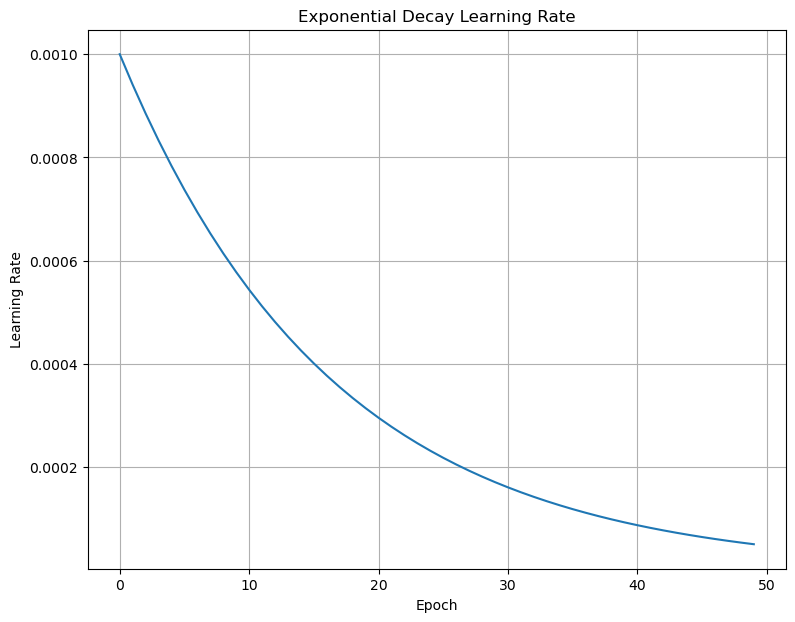

In [32]:
# Plot Exponential Decay learning rate schedules
plt.figure(figsize=(9, 7))
plt.plot(lr_logger.lrs)
plt.title('Exponential Decay Learning Rate')
plt.ylabel('Learning Rate')
plt.xlabel('Epoch')
plt.grid(True)
plt.show()

In [33]:
# 4D) Evaluate train and validation accuracy and loss 
def create_trace(x, y, ylabel, color):
    trace = go.Scatter(x=x,y=y,
                       name=ylabel,
                       marker=dict(color=color),
                       mode="lines+markers", 
                       text=[f"Epoch {epoch}<br>{ylabel}: {value:.4f}" for epoch, value in zip(x, y)], # Custom hover text
                       hoverinfo='text' # Show only custom text on hover
                      )
    return trace

def plot_accuracy_and_loss_plotly(history_object):
    hist = history_object.history
    acc = hist['accuracy']
    val_acc = hist['val_accuracy']
    loss = hist['loss']
    val_loss = hist['val_loss']
    
    epochs = list(range(1, len(acc) + 1))
    
    trace_ta = create_trace(epochs, acc, "Training Accuracy", "#006400") # Green
    trace_va = create_trace(epochs, val_acc, "Validation Accuracy", "#B3000C") # Red
    trace_tl = create_trace(epochs, loss, "Training Loss", "#305CDE") # Blue
    trace_vl = create_trace(epochs, val_loss, "Validation Loss", "#BE93E4") # Purple
   
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Training and Validation Accuracy', 'Training and Validation Loss'))
    
    # Add traces to the first subplot (Accuracy)
    fig.add_trace(trace_ta, row=1, col=1)
    fig.add_trace(trace_va, row=1, col=1)
    
    # Add traces to the second subplot (Loss)
    fig.add_trace(trace_tl, row=1, col=2)
    fig.add_trace(trace_vl, row=1, col=2)
    
    # Update layout for x-axes
    fig.update_xaxes(title_text='Epoch', row=1, col=1)
    fig.update_xaxes(title_text='Epoch', row=1, col=2)
    
    # Update layout for y-axes
    fig.update_yaxes(title_text='Accuracy', range=[0, 1], row=1, col=1)
    fig.update_yaxes(title_text='Loss', row=1, col=2) 
    
    fig.update_layout(height=500, width=1000, title_text="Model Training History", showlegend=True)
    fig.show()

plot_accuracy_and_loss_plotly(history_CNN_Tuned)

The training and validation accuracy and loss curves now shows better performance, staying consistently close. This stable convergence also prevented the model from diverging in the later epochs.  The model is now generalizing better.

In [34]:
# 4E) Evaluate Test prediction accuracy and loss
print("Evaluating model CNN_Tuned on the test set:")
test_loss_CNN_Tuned, test_accuracy_CNN_Tuned = model_CNN_Tuned.evaluate(X_test, y_test, verbose=1)
print(f"Test Accuracy: {test_accuracy_CNN_Tuned:.4f}")
print(f"Test Loss: {test_loss_CNN_Tuned:.4f}")

Evaluating model CNN_Tuned on the test set:
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9191 - loss: 0.2413
Test Accuracy: 0.9187
Test Loss: 0.2316


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


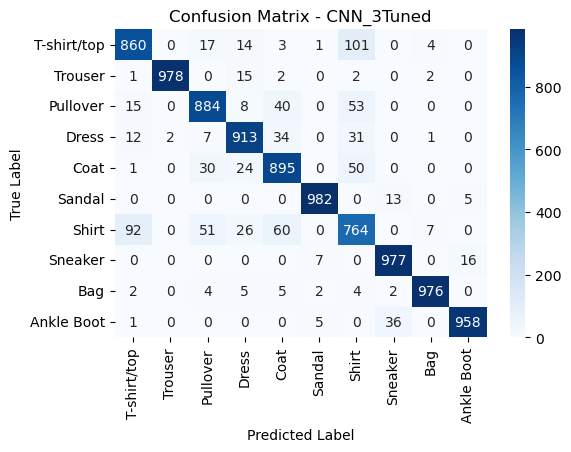


Confusion Matrix - CNN_Tuned (Raw):
[[860   0  17  14   3   1 101   0   4   0]
 [  1 978   0  15   2   0   2   0   2   0]
 [ 15   0 884   8  40   0  53   0   0   0]
 [ 12   2   7 913  34   0  31   0   1   0]
 [  1   0  30  24 895   0  50   0   0   0]
 [  0   0   0   0   0 982   0  13   0   5]
 [ 92   0  51  26  60   0 764   0   7   0]
 [  0   0   0   0   0   7   0 977   0  16]
 [  2   0   4   5   5   2   4   2 976   0]
 [  1   0   0   0   0   5   0  36   0 958]]

Correct predicted classes: 9187 (91.87%)
Incorrect predicted classes: 813 (8.13%)

Classification Report: CNN_Tuned
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.87      1000
     Trouser       1.00      0.98      0.99      1000
    Pullover       0.89      0.88      0.89      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.86      0.90      0.88      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.76      0.76   

In [35]:
# 4F) Evaluate confusion matrix and Classification Report

# Get predictions from the model
y_pred_test_CNN_Tuned = model_CNN_Tuned.predict(X_test)

# Convert predicted labels to class labels 
y_pred_labels_CNN_Tuned = np.argmax(y_pred_test_CNN_Tuned, axis=1) 

# Convert true one-hot encoded labels back to integer class labels
y_true_labels_CNN_Tuned = np.argmax(y_test, axis=1)

# Generate the Confusion Matrix
conf_matrix_CNN_Tuned = confusion_matrix(y_true_labels_CNN_Tuned, y_pred_labels_CNN_Tuned)

# Display the confusion matrix 
plt.figure(figsize=(6, 4)) 
sns.heatmap(conf_matrix_CNN_Tuned, annot=True, fmt='d', cmap='Blues',
            xticklabels=[labels[i] for i in range(NUM_CLASSES)],
            yticklabels=[labels[i] for i in range(NUM_CLASSES)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - CNN_3Tuned')
plt.show()

# Display the confusion matrix raw version
print("\nConfusion Matrix - CNN_Tuned (Raw):")
print(conf_matrix_CNN_Tuned)

# Display number of correct and incorrect predictions.
correct_prediction = np.where(y_true_labels_CNN_Tuned == y_pred_labels_CNN_Tuned)[0]
incorrect_prediction = np.where(y_true_labels_CNN_Tuned != y_pred_labels_CNN_Tuned)[0]

total_prediction = correct_prediction.shape[0] + incorrect_prediction.shape[0]
correct_percentage = (correct_prediction.shape[0] / total_prediction) * 100
incorrect_percentage = (incorrect_prediction.shape[0] / total_prediction) * 100

print("\nCorrect predicted classes:", correct_prediction.shape[0], f"({correct_percentage:.2f}%)")
print("Incorrect predicted classes:", incorrect_prediction.shape[0], f"({incorrect_percentage:.2f}%)")

# Display the Classification Report
print("\nClassification Report: CNN_Tuned")
class_report_CNN_Tuned = classification_report(y_true_labels_CNN_Tuned, y_pred_labels_CNN_Tuned, target_names=[labels[i] for i in range(NUM_CLASSES)])
print(class_report_CNN_Tuned)

### Results

In [36]:
model_summaries = []
model_summaries.append({
    "Model": "CNN_Baseline",
    "Train Accuracy": history_CNN_Baseline.history["accuracy"][-1],
    "Validation Accuracy": history_CNN_Baseline.history["val_accuracy"][-1],
    "Test Accuracy": test_accuracy_CNN_Baseline,
    "Train Loss": history_CNN_Baseline.history["loss"][-1],
    "Validation Loss": history_CNN_Baseline.history["val_loss"][-1],
    "Test Loss": test_loss_CNN_Baseline
})
model_summaries.append({
    "Model": "CNN_Dropout",
    "Train Accuracy": history_CNN_Dropout.history["accuracy"][-1],
    "Validation Accuracy": history_CNN_Dropout.history["val_accuracy"][-1],
    "Test Accuracy": test_accuracy_CNN_Dropout,
    "Train Loss": history_CNN_Dropout.history["loss"][-1],
    "Validation Loss": history_CNN_Dropout.history["val_loss"][-1],
    "Test Loss": test_loss_CNN_Dropout
})
model_summaries.append({
    "Model": "CNN_Deeper",
    "Train Accuracy": history_CNN_Deeper.history["accuracy"][-1],
    "Validation Accuracy": history_CNN_Deeper.history["val_accuracy"][-1],
    "Test Accuracy": test_accuracy_CNN_Deeper,
    "Train Loss": history_CNN_Deeper.history["loss"][-1],
    "Validation Loss": history_CNN_Deeper.history["val_loss"][-1],
    "Test Loss": test_loss_CNN_Deeper
})
model_summaries.append({
    "Model": "CNN_Tuned",
    "Train Accuracy": history_CNN_Tuned.history["accuracy"][-1],
    "Validation Accuracy": history_CNN_Tuned.history["val_accuracy"][-1],
    "Test Accuracy": test_accuracy_CNN_Tuned,
    "Train Loss": history_CNN_Tuned.history["loss"][-1],
    "Validation Loss": history_CNN_Tuned.history["val_loss"][-1],
    "Test Loss": test_loss_CNN_Tuned
})

summary_results = pd.DataFrame(model_summaries)
summary_results 

,Model,Train Accuracy,Validation Accuracy,Test Accuracy,Train Loss,Validation Loss,Test Loss
0,CNN_Baseline,1.000000,0.917500,0.9098,0.000092,0.723165,0.825147
1,CNN_Dropout,0.928104,0.924500,0.9207,0.193507,0.212733,0.229856
2,CNN_Deeper,0.929875,0.922083,0.9175,0.186447,0.220434,0.241332
3,CNN_Tuned,0.923000,0.922833,0.9187,0.205020,0.216046,0.231558


**CNN_Baseline** - The baseline model showed significant overfitting. While it achieved a near-perfect training accuracy of **99.55%**, its validation and test accuracies were substantially lower at **90.95%** and **90.20%**, respectively. This disparity was further confirmed by the large divergence between the training and validation loss curves.  

**CNN_Dropout** - The implementation of Dropout layers greatly improved the model's generalization capabilities. This adjustment increased the test accuracy to **91.53%** while reducing the gap between training and validation loss.

**CNN_Deeper** - By adding an extra convolutional block, the model's performance improved slightly to a test accuracy of **91.84%** (a 0.31% increase over the Dropout model). This suggests that the deeper architecture was able to extract more complex and hierarchical features from the dataset.

**CNN_Tuned** - Further optimization via learning rate hyperparameter tuning resulted in a peak test accuracy of **91.92%** (+0.08%). Notably, this variant achieved the lowest test loss among all four models. This final adjustment refined the training process, allowing the model to converge more effectively and achieve superior generalization.

### Performance Analysis on final model, Model 4. 

* List of incorrectly predicted classes
* Individual image with their confidence predictions.
* Several images with their confidence predictions.

Correct prediction labels are blue and incorrect prediction labels are red.

In [37]:
# Define functions to graph the full set of 10 class predictions.
def plot_image(predictions_array, true_label, image, labels_map):
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(image, cmap=plt.cm.binary)
    predicted_label = np.argmax(predictions_array)
    predicted_confidence = np.max(predictions_array)
    
    if predicted_label == true_label:
        color = 'blue' # Correct prediction 
    else:
        color = 'red' # Incorrect prediction

    plt.xlabel(f"{labels_map[predicted_label]} {100*predicted_confidence:.0f}% \nTrue label: ({labels_map[true_label]})", color=color)

def plot_value_array(predictions_array, true_label, labels_map, num_classes):
    plt.grid(False)
    plt.xticks(range(num_classes), [labels_map[i] for i in range(num_classes)], rotation=90, ha='center')
    plt.yticks([])
    thisplot = plt.bar(range(num_classes), predictions_array, color="#777777") # Default grey bars
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    
    if predicted_label == true_label:
        thisplot[predicted_label].set_color('blue') # Correctly predicted
    else:
        thisplot[true_label].set_color('blue') # Show the true label
        thisplot[predicted_label].set_color('red') # Incorrectly predicted

In [38]:
# List of incorrect predicted classes
print("Incorrect predicted classes:", incorrect_prediction.shape[0])
list_of_incorrect_indices = incorrect_prediction.tolist()
print("List of incorrect prediction indices:\n", list_of_incorrect_indices)

Incorrect predicted classes: 813
List of incorrect prediction indices:
 [23, 25, 29, 42, 49, 57, 67, 68, 98, 135, 147, 150, 153, 213, 229, 244, 283, 312, 316, 324, 361, 374, 378, 381, 382, 389, 396, 410, 441, 444, 452, 454, 457, 460, 510, 511, 529, 547, 565, 569, 578, 600, 607, 628, 634, 635, 664, 669, 670, 685, 688, 711, 724, 732, 747, 753, 760, 787, 800, 817, 851, 860, 881, 905, 921, 937, 938, 963, 965, 966, 977, 979, 994, 1000, 1005, 1025, 1051, 1055, 1056, 1066, 1101, 1104, 1111, 1131, 1139, 1152, 1160, 1162, 1165, 1174, 1191, 1194, 1197, 1210, 1217, 1231, 1235, 1236, 1254, 1280, 1286, 1297, 1300, 1305, 1329, 1336, 1374, 1388, 1396, 1399, 1408, 1425, 1471, 1482, 1487, 1496, 1501, 1509, 1522, 1533, 1543, 1602, 1617, 1626, 1632, 1643, 1645, 1650, 1665, 1682, 1684, 1699, 1701, 1706, 1736, 1743, 1744, 1771, 1810, 1814, 1836, 1842, 1846, 1852, 1856, 1890, 1900, 1910, 1917, 1922, 1942, 1943, 1945, 1953, 1954, 1955, 1964, 1968, 1980, 2001, 2006, 2009, 2037, 2039, 2067, 2071, 2073, 2089, 2

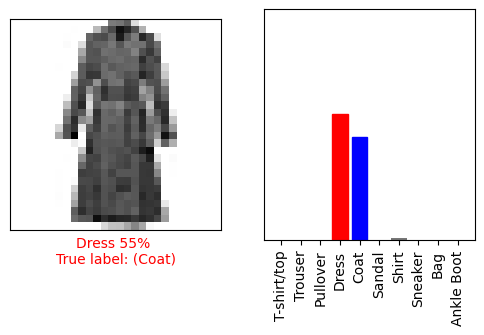

In [39]:
# Individual image with their confidence predictions. Note that the model can be wrong even when very confident.
i = 5070

plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(y_pred_test_CNN_Tuned[i], np.argmax(y_test[i]), test_images[i], labels)
plt.subplot(1,2,2)
plot_value_array(y_pred_test_CNN_Tuned[i], np.argmax(y_test[i]), labels, NUM_CLASSES)
plt.show()

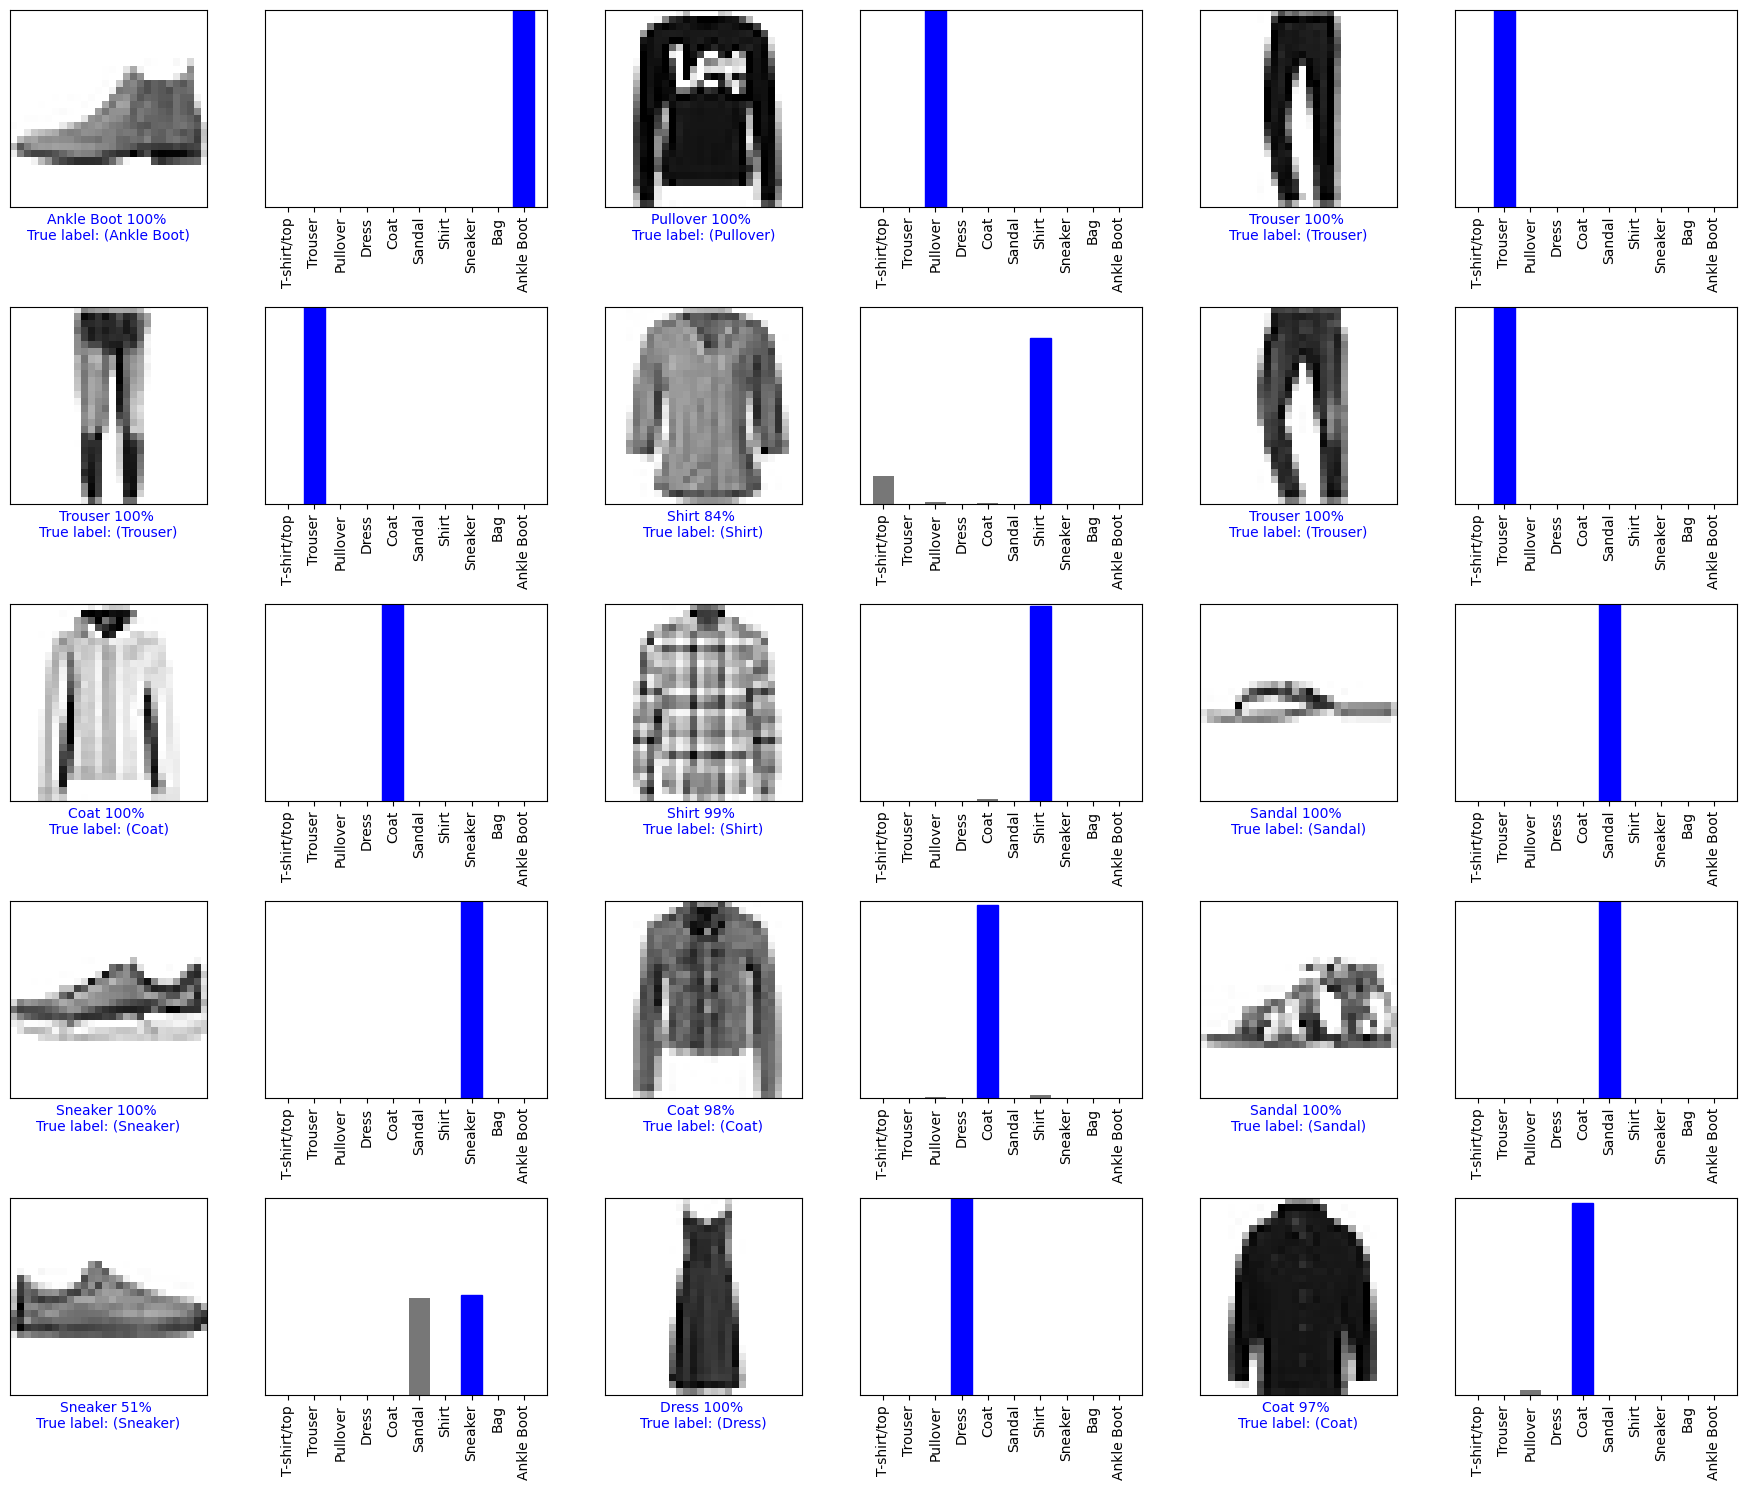

In [40]:
# Several images with their confidence predictions. Note that the model can be wrong even when very confident.
num_rows = 5 # Number of rows 
num_cols = 3 # Number of columns pair wise, 1 for image, 1 for bar chart

# Total number of columns in the subplot grid
num_total_subplot_cols = num_cols * 2 

# Total number of image-chart pairs to plot across all rows
total_pairs_to_plot = num_rows * num_cols

# Configuration for the image layout
figure_width = 6 * num_cols
figure_height = 3 * num_rows
plt.figure(figsize=(figure_width, figure_height))

# Plot image-bar chart 
for i in range(total_pairs_to_plot):
    # Plot the image
    plt.subplot(num_rows, num_total_subplot_cols, (i * 2) + 1)
    plot_image(y_pred_test_CNN_Tuned[i], np.argmax(y_test[i]), test_images[i], labels)

    # Plot the value array
    plt.subplot(num_rows, num_total_subplot_cols, (i * 2) + 2)
    plot_value_array(y_pred_test_CNN_Tuned[i], np.argmax(y_test[i]), labels, NUM_CLASSES) 

plt.tight_layout()
plt.show()

### Saving the Model for Deployment 

In [43]:
model_CNN_Tuned.save('../app/trained_model/trained_model.keras')

### Conclusion
This project demostrated a textbook example of a methodical machine learning workflow, began with a baseline model, diagnosed its primary weaknesses (overfitting), implemented a solution (dropout), incrementally improved the model by adding more complexity (a deeper architecture), and finally optimized the training process through hyperparameter tuning (learning rate tuning). The results showed the positive impact of these architectural modifications and hyperparameter tuning. The CNN_Tuned model, which incorporated all of these improvements, achieved the most optimized performance and exhibited the highest generalization ability.

While the final model performed well, it is not perfect. The persistent confusion between certain classes could be from the dataset's inherent difficulty due to the low resolution of the 28x28 pixel grayscale images. At this scale, subtle visual features that distinguish certain particles of clothing, such as a coat's buttons or a shirt's collar, may be barely visible. This makes it challenging for the network to differentiate between very similar items, which can look nearly identical from the network's perspective.

### Reference

[1] Neural Networks and Deep Learning, http://neuralnetworksanddeeplearning.com/index.html

[2] TensorFlow Basic classification: Classify images of clothing, https://www.tensorflow.org/tutorials/keras/classification

[3] Deep Diving into Neural Networks: Understanding FNN, CNN, and RNN, https://medium.com/@kisetzuu/deep-diving-into-neural-networks-understanding-fnn-cnn-and-rnn-3345b73676a2

[4] Dropout: A Simple Way to Prevent Neural Networks from Overfitting, https://www.cs.toronto.edu/~hinton/absps/JMLRdropout.pdf

[5] Keras ExponentialDecay, https://keras.io/api/optimizers/learning_rate_schedules/exponential_decay/


### Resources

[1] Fashion-MNIST dataset, https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data

[2] NN-SVG Publication-ready NN-architecture schematics, https://alexlenail.me/NN-SVG/AlexNet.html

